In [1]:
import scanpy as sc
import anndata as ad
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
import model.uot_alignment as al
import model.uot_alignment_trans as alt
import matplotlib.pyplot as plt
import squidpy as sq
import scvi, os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors, radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
adata = sc.read_h5ad("data/GP1/processed/GP1_with_metadata.h5ad")
adata.obs["cluster"] = adata.obs["cluster"].astype(str).astype("category")

spatial libraries: ['1-KZ1']


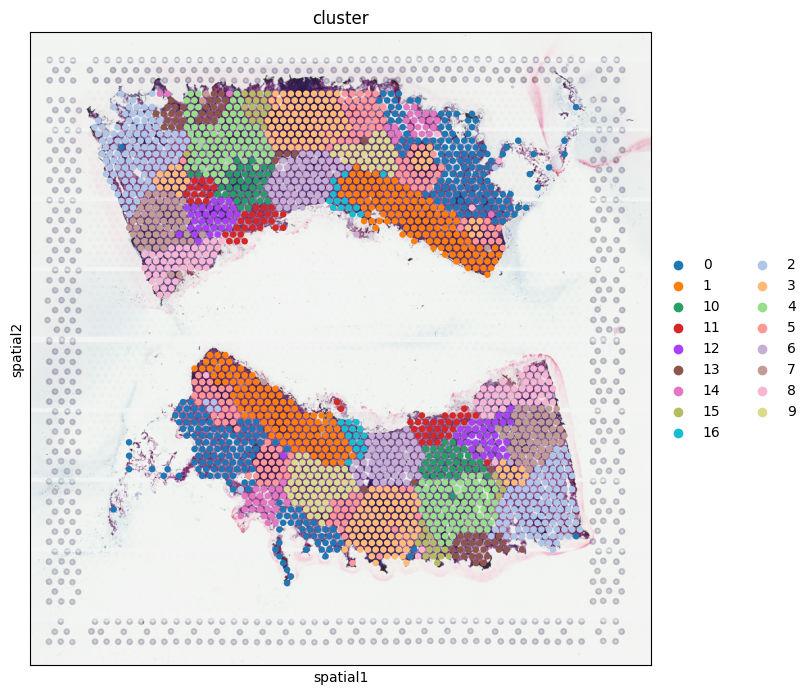

In [4]:
print("spatial libraries:", list(adata.uns["spatial"].keys()))

lib = list(adata.uns["spatial"].keys())[0]

sq.pl.spatial_scatter(
    adata,
    library_id=lib,
    color="cluster",   
    img=True,
    size=1.3,
    legend_loc="right margin",
    figsize=(8, 8),
)
plt.show()

In [5]:
adata.obs["cluster"] = adata.obs["cluster"].astype(str)
adata.obs["cluster"] = adata.obs["cluster"].replace({"16": "1"})
adata.obs["cluster"] = adata.obs["cluster"].astype("category")

In [6]:
model_dir = os.path.join("outputs/GP1/ckpt/scvi", "scanvi")
model =  scvi.model.SCANVI.load(model_dir)
SCVI_LATENT_KEY = "X_scanVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/project/src/GP1_ckpt/scvi/scanvi/model.pt already downloaded                            


(2174, 10)

In [7]:
adata.obs['cluster'].value_counts()

cluster
0     288
1     282
2     228
3     213
4     180
5     151
6     131
7     125
8     106
9      97
10     77
11     72
12     71
13     63
14     53
15     37
Name: count, dtype: int64

In [8]:
def split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",
    normal_clusters=("7", "8", "12"),
    pmc_clusters=("11",),
    cancer_clusters=("6", "9", "1"),
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"adata.obs missing {cluster_col}")

    if "spatial" not in adata.obsm:
        raise KeyError("adata.obsm missing 'spatial'")

    ad = adata.copy()

    # 1) cluster ,( 16 -> 1)
    ad.obs[cluster_col] = ad.obs[cluster_col].astype(str)
    # 2)  cluster
    normal_clusters = set(map(str, normal_clusters))
    pmc_clusters = set(map(str, pmc_clusters))
    cancer_clusters = set(map(str, cancer_clusters))

    keep_clusters = normal_clusters | pmc_clusters | cancer_clusters
    ad = ad[ad.obs[cluster_col].isin(keep_clusters)].copy()

    # 3)  status: normal / PMC_P / cancer
    status = np.full(ad.n_obs, None, dtype=object)

    mask_normal = ad.obs[cluster_col].isin(normal_clusters).values
    mask_pmc = ad.obs[cluster_col].isin(pmc_clusters).values
    mask_cancer = ad.obs[cluster_col].isin(cancer_clusters).values

    status[mask_normal] = "normal"
    status[mask_pmc] = "PMC_P"
    status[mask_cancer] = "cancer"

    if pd.isna(status).any() or (status == None).any():
        raise ValueError(" status  cluster, cluster .")

    ad.obs["status"] = pd.Categorical(
        status,
        categories=["normal", "PMC_P", "cancer"],
        ordered=True
    )

    # 4)  spatial  y  upper / lower
    xy = np.asarray(ad.obsm["spatial"])
    if xy.shape[1] < 2:
        raise ValueError("adata.obsm['spatial'] requirescolumncoordinates (x, y)")

    y = xy[:, 1].reshape(-1, 1)

    km = KMeans(n_clusters=2, random_state=0, n_init=10)
    grp = km.fit_predict(y)

    means = {g: float(y[grp == g].mean()) for g in np.unique(grp)}
    upper_grp = min(means, key=means.get)   # y 

    ad.obs["tissue_side"] = np.where(grp == upper_grp, "upper", "lower")
    ad.obs["tissue_side"] = pd.Categorical(
        ad.obs["tissue_side"],
        categories=["upper", "lower"],
        ordered=True
    )

    # 5)  upper / lower,internal status
    adata_upper = ad[ad.obs["tissue_side"] == "upper"].copy()
    adata_lower = ad[ad.obs["tissue_side"] == "lower"].copy()

    # cluster ,
    uniq_clusters = sorted(ad.obs[cluster_col].astype(str).unique(), key=lambda x: int(x))
    ad.obs[cluster_col] = pd.Categorical(ad.obs[cluster_col], categories=uniq_clusters, ordered=True)
    adata_upper.obs[cluster_col] = pd.Categorical(adata_upper.obs[cluster_col], categories=uniq_clusters, ordered=True)
    adata_lower.obs[cluster_col] = pd.Categorical(adata_lower.obs[cluster_col], categories=uniq_clusters, ordered=True)

    return {
        "adata_sub": ad,
        "adata_upper": adata_upper,
        "adata_lower": adata_lower,
    }

In [9]:
res = split_cluster_state_upper_lower(adata)

adata_sub = res["adata_sub"]
adata_upper = res["adata_upper"]
adata_lower = res["adata_lower"]

/tmp/ipykernel_1880088/3979091130.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=["cluster", "tissue_side"], spot_size=150)


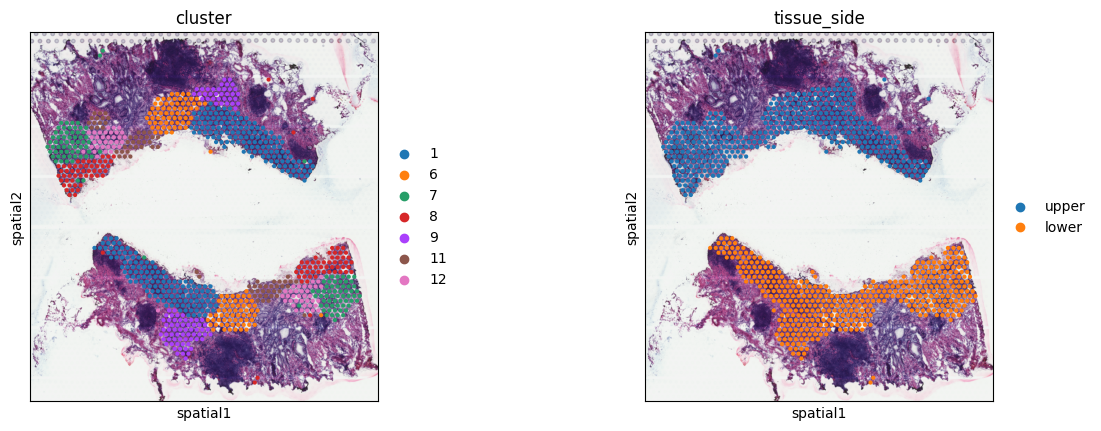

/tmp/ipykernel_1880088/3979091130.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper, color=["cluster"], spot_size=150)


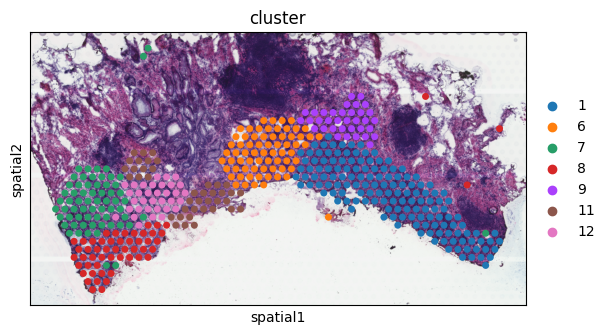

/tmp/ipykernel_1880088/3979091130.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper, color=["cluster"], spot_size=150)


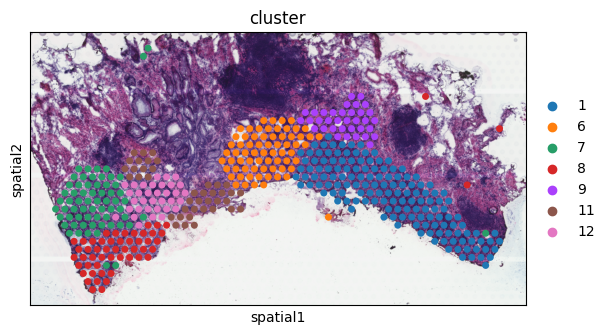

In [10]:
sc.pl.spatial(adata_sub, color=["cluster", "tissue_side"], spot_size=150)
sc.pl.spatial(adata_upper, color=["cluster"], spot_size=150)
sc.pl.spatial(adata_upper, color=["cluster"], spot_size=150)

In [11]:
def keep_largest_spatial_component(
    adata,
    spatial_key="spatial",
    radius=None,
    radius_scale=1.35,
    return_mask=False,
    verbose=True,
):
    """
    .
    radius ,.
    """
    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm missing {spatial_key}")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm['{spatial_key}'] must n x 2")

    if adata.n_obs <= 1:
        return (adata.copy(), np.ones(adata.n_obs, dtype=bool)) if return_mask else adata.copy()

    # :
    if radius is None:
        nn = NearestNeighbors(n_neighbors=2)
        nn.fit(xy)
        dists, _ = nn.kneighbors(xy)
        nn1 = dists[:, 1]
        base = float(np.median(nn1[np.isfinite(nn1)]))
        radius = radius_scale * base

    # :
    G = radius_neighbors_graph(xy, radius=radius, mode="connectivity", include_self=False)
    n_comp, labels = connected_components(G, directed=False)

    comp_sizes = np.bincount(labels)
    largest_label = np.argmax(comp_sizes)
    keep_mask = (labels == largest_label)

    if verbose:
        print(f"radius = {radius:.3f}")
        print(f"n_components = {n_comp}")
        print(f"largest component size = {comp_sizes[largest_label]}/{adata.n_obs}")
        print(f"dropped = {(~keep_mask).sum()}")

    out = adata[keep_mask].copy()
    return (out, keep_mask) if return_mask else out

In [12]:
adata_upper_clean = keep_largest_spatial_component(adata_upper)
adata_lower_clean = keep_largest_spatial_component(adata_lower)

radius = 268.650
n_components = 6
largest component size = 432/438
dropped = 6
radius = 268.650
n_components = 4
largest component size = 441/446
dropped = 5


/tmp/ipykernel_1880088/4185026621.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=["cluster", "tissue_side"], spot_size=150)


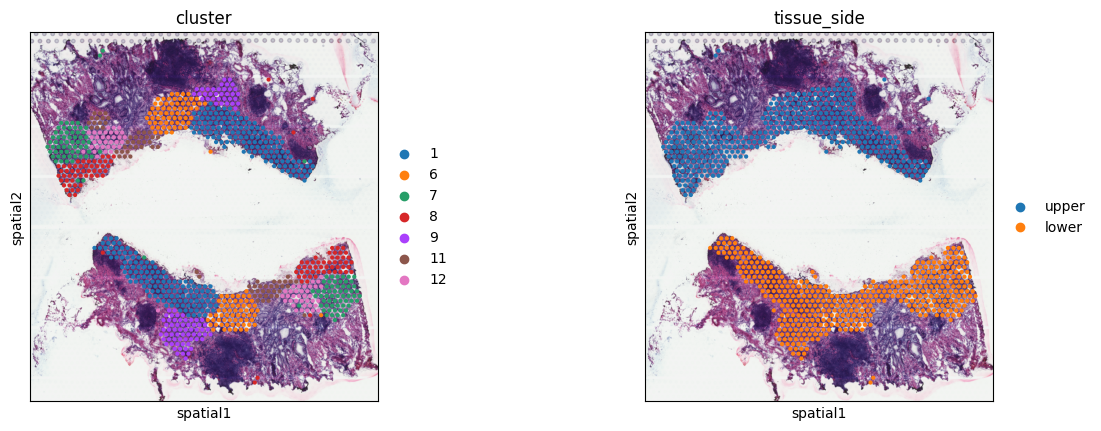

/tmp/ipykernel_1880088/4185026621.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_clean, color=["cluster"], spot_size=150)


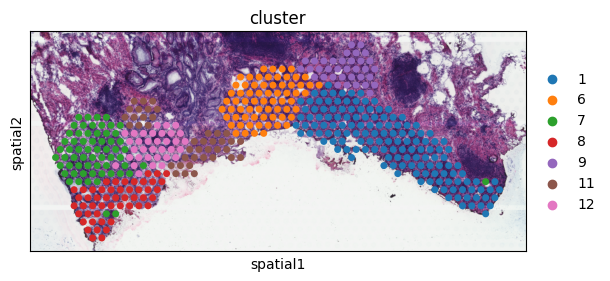

/tmp/ipykernel_1880088/4185026621.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)


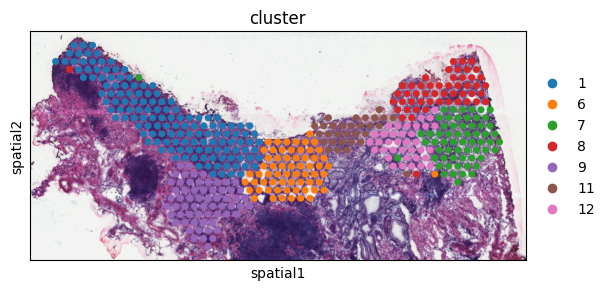

In [13]:
sc.pl.spatial(adata_sub, color=["cluster", "tissue_side"], spot_size=150)
sc.pl.spatial(adata_upper_clean, color=["cluster"], spot_size=150)
sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)

In [14]:
adata_lower_clean.write_h5ad("data/GP1/processed/GP1_lower.h5ad")
adata_upper_clean.write_h5ad("data/GP1/processed/GP1_upper.h5ad")

In [15]:
adata_lower2 = adata_lower_clean.copy()
adata_upper2 = adata_upper_clean.copy()

for x in [adata_lower2, adata_upper2]:
    if "pos" in x.obs.columns:
        x.obs = x.obs.loc[:, ~x.obs.columns.duplicated()].copy()
        x.obs.drop(columns=["pos"], errors="ignore", inplace=True)

adata_lower2.obs["pos"] = "lower"
adata_upper2.obs["pos"] = "upper"

adata_merge = ad.concat(
    [adata_lower2, adata_upper2],
    axis=0,
    join="outer",
    merge="same",
    index_unique=None,
)

adata_merge.obs["pos"] = pd.Categorical(
    adata_merge.obs["pos"].astype(str),
    categories=["lower", "upper"],
    ordered=True
)

adata_merge.obs = adata_merge.obs.loc[:, ~adata_merge.obs.columns.duplicated()].copy()

In [16]:
# adata_merge.obs['pos'].value_counts()
adata_merge

AnnData object with n_obs × n_vars = 873 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'status', 'tissue_side', 'pos'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

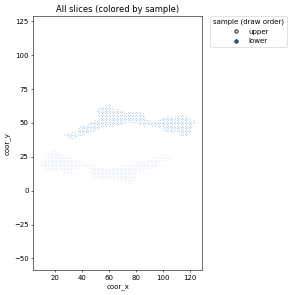

In [17]:
obs = adata_merge.obs.copy()
x_all = obs["array_col"].to_numpy()
y_all = obs["array_row"].to_numpy()
samples = obs["pos"].astype("category")
cats = list(samples.cat.categories)
plot_order = list(reversed(cats))
cmap = plt.get_cmap("tab20")
color_map = {cat: cmap(i % 20) for i, cat in enumerate(cats)}

plt.figure(figsize=(6,6), dpi=50)

for cat in plot_order:
    mask = (samples.to_numpy() == cat)
    plt.scatter(
        x_all[mask],
        y_all[mask],
        s=3,
        c=[color_map[cat]],
        linewidths=0,
        alpha=0.3,
        label=str(cat),         
    )

plt.xlabel("coor_x")
plt.ylabel("coor_y")
plt.title("All slices (colored by sample)")

handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='none',
        markerfacecolor=color_map[cat],
        markersize=5,
        label=str(cat)
    )
    for cat in plot_order
]
plt.legend(
    handles=handles,
    title="sample (draw order)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.axis("equal")
plt.tight_layout()
plt.show()

In [18]:
import importlib
importlib.reload(al)

ad_work = adata_merge.copy()
obs = ad_work.obs

# ----------  1D column ----------
def get_1d_col(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        print(f"[warn] {col!r} has duplicated columns,using first column")
        x = x.iloc[:, 0]
    return x

pos_col = get_1d_col(obs, "pos").astype(str)
cluster_col = get_1d_col(obs, "cluster").astype(str)
array_col = pd.to_numeric(get_1d_col(obs, "array_col"), errors="coerce")
array_row = pd.to_numeric(get_1d_col(obs, "array_row"), errors="coerce")

ref_sample = "upper"
all_samples = [x for x in pd.unique(pos_col) if pd.notna(x)]

print("All samples:", all_samples)
print("Reference sample:", ref_sample)

# ---------- coordinates ----------
XY_all = np.column_stack([
    array_col.to_numpy(dtype=np.float32),
    array_row.to_numpy(dtype=np.float32),
])

xy_min = np.nanmin(XY_all, axis=0)
xy_max = np.nanmax(XY_all, axis=0)
xy_scale = (xy_max - xy_min).astype(np.float32)
xy_scale[xy_scale == 0] = 1.0

def xy_norm(X):
    X = np.asarray(X, dtype=np.float32)
    return (X - xy_min) / xy_scale

def xy_denorm(Xn):
    Xn = np.asarray(Xn, dtype=np.float32)
    return Xn * xy_scale + xy_min

# ----------  ----------
def rotate_about_center(X, deg=180):
    X = np.asarray(X, dtype=np.float32)
    theta = np.deg2rad(deg).astype(np.float32)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    mu = X.mean(axis=0, keepdims=True)
    return (X - mu) @ R.T + mu

print("Normalize params:")
print("  xy_min =", xy_min)
print("  xy_max =", xy_max)

# ---------- outputcolumn ----------
for k in ["cx_aligned", "cy_aligned", "cx_aligned_norm", "cy_aligned_norm"]:
    if k not in ad_work.obs.columns:
        ad_work.obs[k] = np.nan

obs = ad_work.obs
cx_idx  = obs.columns.get_loc("cx_aligned")
cy_idx  = obs.columns.get_loc("cy_aligned")
cxn_idx = obs.columns.get_loc("cx_aligned_norm")
cyn_idx = obs.columns.get_loc("cy_aligned_norm")

def rows_of_pos(name):
    return np.flatnonzero(pos_col.to_numpy() == str(name))

def assign_coords(rows, X_orig, X_norm):
    if len(rows) != len(X_orig) or len(rows) != len(X_norm):
        raise ValueError(
            f"mismatch: rows={len(rows)}, X_orig={len(X_orig)}, X_norm={len(X_norm)}"
        )
    obs.iloc[rows, cx_idx]  = X_orig[:, 0]
    obs.iloc[rows, cy_idx]  = X_orig[:, 1]
    obs.iloc[rows, cxn_idx] = X_norm[:, 0]
    obs.iloc[rows, cyn_idx] = X_norm[:, 1]

# ----------  ----------
rows_ref = rows_of_pos(ref_sample)
if len(rows_ref) == 0:
    raise ValueError(f"missingfind pos == {ref_sample!r} ")

X_ref_orig = XY_all[rows_ref]
X_ref_norm = xy_norm(X_ref_orig)
ann_ref = cluster_col.iloc[rows_ref].to_numpy()

assign_coords(rows_ref, X_ref_orig, X_ref_norm)

# ----------  ----------
for s in all_samples:
    if s == ref_sample:
        continue

    print(f"\n=== Registering {s} → {ref_sample} ===")

    rows_s = rows_of_pos(s)
    if len(rows_s) == 0:
        print(f"[skip] {s} missing")
        continue

    X_src_orig = XY_all[rows_s]
    X_src_norm = xy_norm(X_src_orig)
    ann_src = cluster_col.iloc[rows_s].to_numpy()

    # important:lower  180 
    if s == "lower":
        X_src_norm_init = rotate_about_center(X_src_norm, deg=180)
        print("[init] lower rotate around own centroid first 180°")
    else:
        X_src_norm_init = X_src_norm

    X_src_aligned, info = al.register_slice_to_ref_robust(
        X_src_norm_init,
        X_ref_norm,
        ann_src=ann_src,
        ann_ref=ann_ref,
        n_sub=3000,
        n_starts=3,
        reg=None,
        reg_m=1.0,
        icp_iter=80,
        icp_sub=10000,
        use_class_after=0,
        verbose=True,
    )

    print("final theta:", info["refine"]["theta"])
    print("final t:", info["refine"]["t"])

    X_src_warped_orig = xy_denorm(X_src_aligned)
    assign_coords(rows_s, X_src_warped_orig, X_src_aligned)

print("\nDone.")
print("result written to ad_work.obs:")
print("  cx_aligned, cy_aligned")
print("  cx_aligned_norm, cy_aligned_norm")

All samples: ['lower', 'upper']
Reference sample: upper
Normalize params:
  xy_min = [10.  6.]
  xy_max = [123.  64.]

=== Registering lower → upper ===
[init] lower 先绕自身质心旋转 180°


UOT init:   0%|          | 0/9 [00:00<?, ?it/s, best=0.01388, reg=0.00772, score=0.02156, th=0.0887, trial=9]


[UOT init] BEST score=0.013879 reg=0.00193087 theta=0.0874 t=[-0.28105686404546804, -0.5172062059961045]


ICP refine: 100%|██████████| 80/80 [00:00<00:00, 165.91it/s, cls=1, med=0.006707, p90=0.01514, th=0.0957, tx=-0.282, ty=-0.516]


final theta: 0.09566092927281475
final t: [-0.28243273230760285, -0.5159648149003926]

Done.
结果写在 ad_work.obs:
  cx_aligned, cy_aligned
  cx_aligned_norm, cy_aligned_norm


x_orig_col = array_col
y_orig_col = array_row
x_warp_col = cx_aligned
y_warp_col = cy_aligned
ann_col    = cluster
group_col  = pos


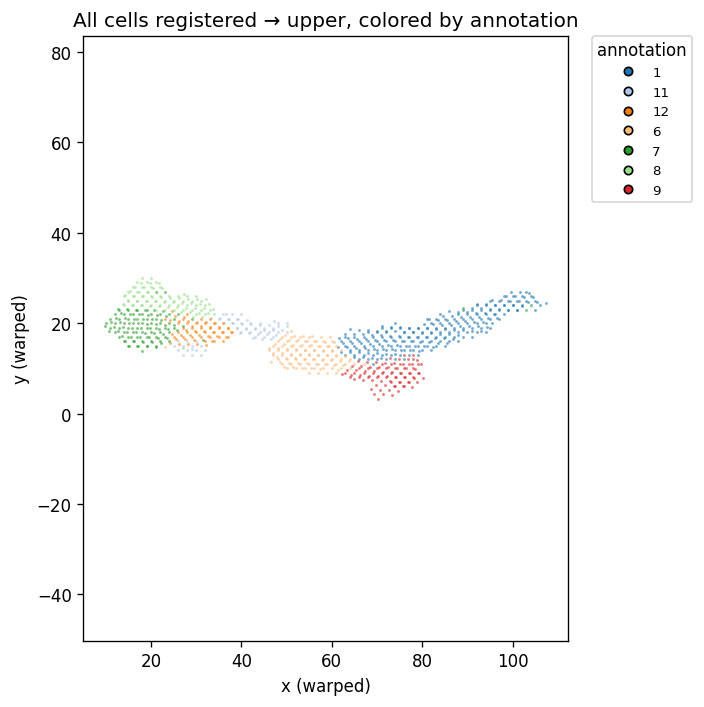

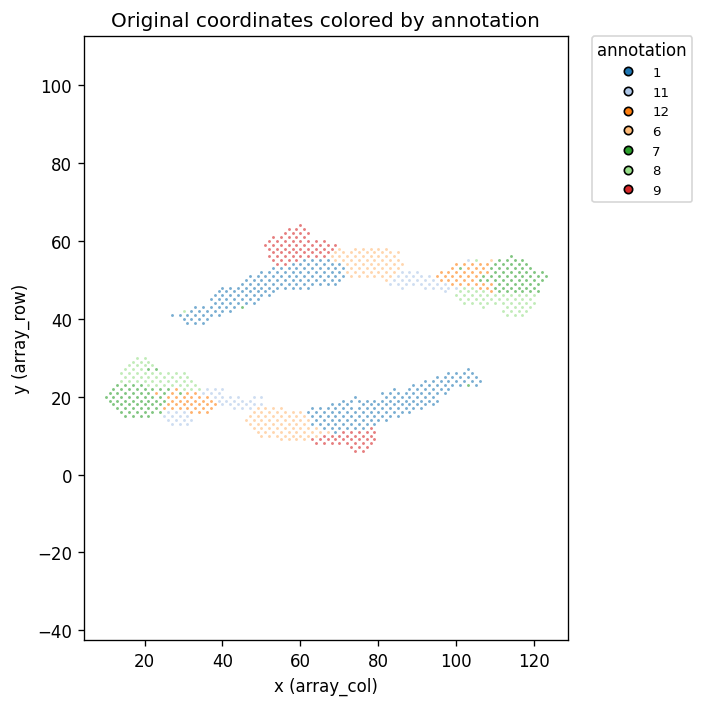

pos = lower
before bbox: (np.float64(96.0), np.float64(25.0))
after  bbox: (np.float64(97.42198657989502), np.float64(25.68929362297058))


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 
#  ad_work;missing adata_merge
# =========================
if "ad_work" in globals():
    ad_show = ad_work
elif "adata_merge" in globals():
    ad_show = adata_merge
else:
    raise ValueError("find ad_work  adata_merge")

obs = ad_show.obs

# =========================
#  1D column,column DataFrame
# =========================
def get_1d_col(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        print(f"[warn] {col!r} has duplicated columns,using first column")
        x = x.iloc[:, 0]
    return x

def find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"column: {candidates}")

# =========================
# column
# =========================
x_orig_col = find_first_existing_col(obs, ["coor_x", "array_col", "cx"])
y_orig_col = find_first_existing_col(obs, ["coor_y", "array_row", "cy"])
x_warp_col = find_first_existing_col(obs, ["cx_aligned"])
y_warp_col = find_first_existing_col(obs, ["cy_aligned"])
ann_col    = find_first_existing_col(obs, ["annotation", "cluster", "status"])
group_col  = find_first_existing_col(obs, ["pos", "sample"])

print("x_orig_col =", x_orig_col)
print("y_orig_col =", y_orig_col)
print("x_warp_col =", x_warp_col)
print("y_warp_col =", y_warp_col)
print("ann_col    =", ann_col)
print("group_col  =", group_col)

# =========================
# 
# =========================
ann_vals = get_1d_col(obs, ann_col).astype(str)
ann_cats = pd.Categorical(ann_vals).categories.tolist()

cmap = plt.get_cmap("tab20")
ann_color_map = {ann: cmap(i % 20) for i, ann in enumerate(ann_cats)}

# =========================
# 
# =========================
def plot_scatter_by_annotation(df, x_col, y_col, ann_col, title, xlabel, ylabel, s=3, alpha=0.6):
    df = df.copy()
    df = df[np.isfinite(df[x_col]) & np.isfinite(df[y_col])].copy()

    plt.figure(figsize=(6, 6), dpi=120)

    for ann in ann_cats:
        m = (df[ann_col].astype(str) == str(ann))
        if m.sum() == 0:
            continue
        plt.scatter(
            df.loc[m, x_col],
            df.loc[m, y_col],
            s=s,
            c=[ann_color_map[ann]],
            alpha=alpha,
            linewidths=0,
            label=str(ann)
        )

    plt.axis("equal")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=ann_color_map[ann],
            markersize=5,
            label=str(ann)
        )
        for ann in ann_cats
    ]
    plt.legend(
        handles=handles,
        title=ann_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8
    )
    plt.tight_layout()
    plt.show()

# =========================
# 1) coordinates
# =========================
df_warp = pd.DataFrame({
    "x": pd.to_numeric(get_1d_col(obs, x_warp_col), errors="coerce").to_numpy(),
    "y": pd.to_numeric(get_1d_col(obs, y_warp_col), errors="coerce").to_numpy(),
    "annotation": get_1d_col(obs, ann_col).astype(str).to_numpy(),
    "group": get_1d_col(obs, group_col).astype(str).to_numpy(),
})

plot_scatter_by_annotation(
    df=df_warp,
    x_col="x",
    y_col="y",
    ann_col="annotation",
    title="All cells registered → upper, colored by annotation",
    xlabel="x (warped)",
    ylabel="y (warped)",
)

# =========================
# 2) coordinates
# =========================
df_orig = pd.DataFrame({
    "x": pd.to_numeric(get_1d_col(obs, x_orig_col), errors="coerce").to_numpy(),
    "y": pd.to_numeric(get_1d_col(obs, y_orig_col), errors="coerce").to_numpy(),
    "annotation": get_1d_col(obs, ann_col).astype(str).to_numpy(),
    "group": get_1d_col(obs, group_col).astype(str).to_numpy(),
})

plot_scatter_by_annotation(
    df=df_orig,
    x_col="x",
    y_col="y",
    ann_col="annotation",
    title="Original coordinates colored by annotation",
    xlabel=f"x ({x_orig_col})",
    ylabel=f"y ({y_orig_col})",
)

# =========================
# 3)  bbox 
#  pos , lower
# =========================
def bbox_size(X):
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    if len(X) == 0:
        return np.nan, np.nan
    w = X[:, 0].max() - X[:, 0].min()
    h = X[:, 1].max() - X[:, 1].min()
    return w, h

group_to_check = "lower"   #  "upper"

group_vals = get_1d_col(obs, group_col).astype(str)
mask_g = (group_vals == group_to_check).to_numpy()

X_before = np.column_stack([
    pd.to_numeric(get_1d_col(obs, x_orig_col), errors="coerce").to_numpy()[mask_g],
    pd.to_numeric(get_1d_col(obs, y_orig_col), errors="coerce").to_numpy()[mask_g],
])

X_after = np.column_stack([
    pd.to_numeric(get_1d_col(obs, x_warp_col), errors="coerce").to_numpy()[mask_g],
    pd.to_numeric(get_1d_col(obs, y_warp_col), errors="coerce").to_numpy()[mask_g],
])

print(f"{group_col} = {group_to_check}")
print("before bbox:", bbox_size(X_before))
print("after  bbox:", bbox_size(X_after))

In [20]:
adata_merge.obs['pos'].value_counts()

pos
lower    441
upper    432
Name: count, dtype: int64

In [21]:
ad_show

AnnData object with n_obs × n_vars = 873 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'status', 'tissue_side', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

In [22]:
adata_lower_clean = ad_show[ad_show.obs['pos']=='lower']
adata_lower_clean.obs['status'].value_counts()

status
cancer    263
normal    148
PMC_P      30
Name: count, dtype: int64

In [23]:
adata_upper_clean = ad_show[ad_show.obs['pos']=='upper']
adata_upper_clean.obs['status'].value_counts()

status
cancer    246
normal    146
PMC_P      40
Name: count, dtype: int64

/tmp/ipykernel_1880088/1849075661.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


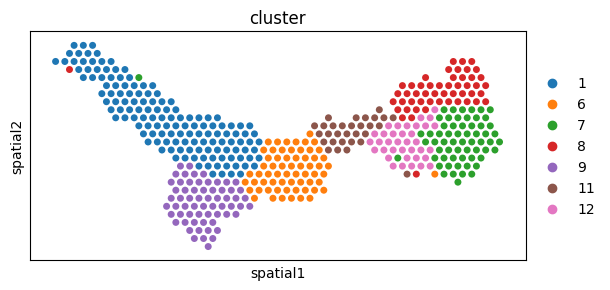

In [43]:
sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)

In [47]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

rng = np.random.default_rng(2025)

ad = adata_lower_clean.copy()
obs = ad.obs.copy()
cluster = obs["cluster"].astype(str).to_numpy()

x_col, y_col = "cx_aligned", "cy_aligned"
coords = obs[[x_col, y_col]].to_numpy(dtype=float)

# 6
tree = cKDTree(coords)
_, nn_idx = tree.query(coords, k=min(7, len(obs)))   # +6
nn_idx = nn_idx[:, 1:]                               # 

nbr_cluster = cluster[nn_idx]

same_cnt = (nbr_cluster == cluster[:, None]).sum(axis=1)
n1_cnt   = (nbr_cluster == "1").sum(axis=1)
nN_cnt   = np.isin(nbr_cluster, ["7", "8", "12"]).sum(axis=1)

# ""
mask_bad = (
    # 7/8/12  1 : <=1,41
    (np.isin(cluster, ["7", "8", "12"]) & (same_cnt <= 1) & (n1_cnt >= 4))
    |
    # 6  normal(7/8/12) : <=1,47/8/12
    ((cluster == "6") & (same_cnt <= 1) & (nN_cnt >= 4))
)

print(":", int(mask_bad.sum()))
print(obs.loc[mask_bad, ["status", "cluster", x_col, y_col]])

# 
ad_qc = ad[~mask_bad].copy()
obs_qc = ad_qc.obs

# 
keep_idx = []
for st, n_target in {"cancer": 246, "normal": 145}.items():
    idx = obs_qc.index[obs_qc["status"] == st].to_numpy()
    n_take = min(n_target, len(idx))
    keep_idx.extend(rng.choice(idx, size=n_take, replace=False).tolist())

# PMC_P 
keep_idx.extend(obs_qc.index[obs_qc["status"] == "PMC_P"].to_list())

adata_lower_ds = ad_qc[list(dict.fromkeys(keep_idx))].copy()

将删除的点数: 3
                    status cluster  cx_aligned  cy_aligned
AGGACGACCCATTAGA-1  normal       7   89.030144   23.452398
CCTTGACCACTTTATT-1  cancer       6   23.089676   14.644889
CGCTTATTCCCGGTCG-1  normal       8  104.147667   23.712448


In [50]:
adata_lower_ds.obs['status'].value_counts()

status
cancer    246
normal    145
PMC_P      30
Name: count, dtype: int64

/tmp/ipykernel_1880088/3854331490.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_ds, color=["cluster"], spot_size=150)


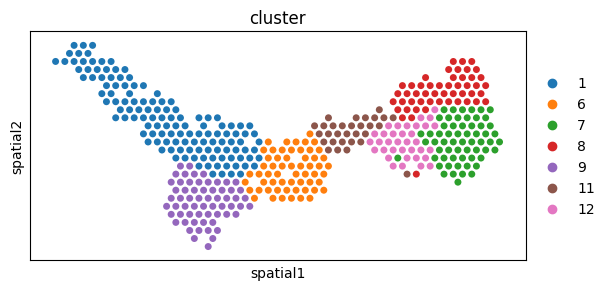

In [51]:
sc.pl.spatial(adata_lower_ds, color=["cluster"], spot_size=150)

In [52]:
adata_lower_ds

AnnData object with n_obs × n_vars = 421 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'status', 'tissue_side', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

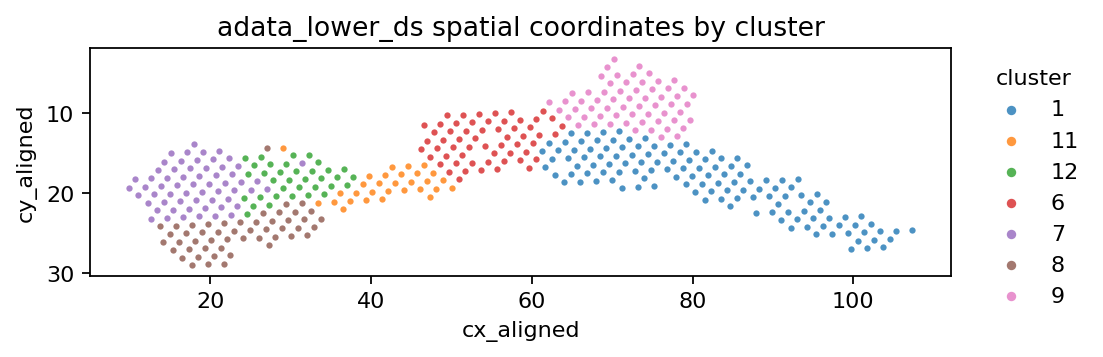

In [53]:
df = adata_lower_ds.obs.copy()
df["cluster"] = df["cluster"].astype(str)

plt.figure(figsize=(7, 7), dpi=160)

for cl, sub in df.groupby("cluster", sort=True):
    plt.scatter(
        sub["cx_aligned"],
        sub["cy_aligned"],
        s=8,
        alpha=0.8,
        linewidths=0,
        label=cl
    )

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()   
plt.xlabel("cx_aligned")
plt.ylabel("cy_aligned")
plt.title("adata_lower_ds spatial coordinates by cluster")
plt.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    markerscale=1.5,
    frameon=False
)
plt.tight_layout()
plt.show()

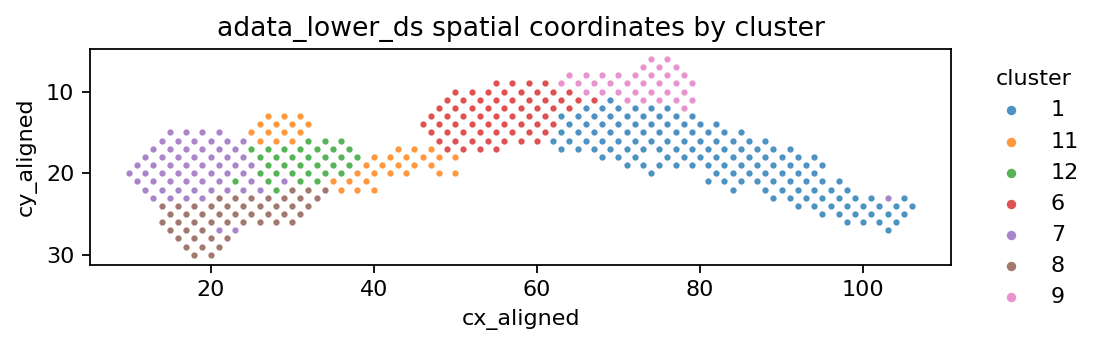

In [54]:
df = adata_upper_clean.obs.copy()
df["cluster"] = df["cluster"].astype(str)

plt.figure(figsize=(7, 7), dpi=160)

for cl, sub in df.groupby("cluster", sort=True):
    plt.scatter(
        sub["cx_aligned"],
        sub["cy_aligned"],
        s=8,
        alpha=0.8,
        linewidths=0,
        label=cl
    )

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()   # 
plt.xlabel("cx_aligned")
plt.ylabel("cy_aligned")
plt.title("adata_lower_ds spatial coordinates by cluster")
plt.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    markerscale=1.5,
    frameon=False
)
plt.tight_layout()
plt.show()

In [55]:
adata_lower_ds_no_pmc = adata_lower_ds[
    adata_lower_ds.obs["status"].astype(str) != "PMC_P"
].copy()

In [56]:
adata_lower_ds_no_pmc.obs["status"].value_counts()

status
cancer    246
normal    145
Name: count, dtype: int64

In [57]:
adata_lower_ds_no_pmc.obsm["spatial_aligned_init"] = adata_lower_ds_no_pmc.obs[["cx_aligned", "cy_aligned"]].to_numpy(dtype=float)
adata_lower_ds_no_pmc

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'status', 'tissue_side', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init'
    varm: 'PCs'
    layers: 'counts'

In [58]:
adata_lower_ds.obsm["spatial_aligned_init"] = adata_lower_ds.obs[["cx_aligned", "cy_aligned"]].to_numpy(dtype=float)
adata_lower_ds

AnnData object with n_obs × n_vars = 421 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'status', 'tissue_side', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init'
    varm: 'PCs'
    layers: 'counts'

In [59]:
adata_lower_ds_no_pmc.write_h5ad("data/GP1/processed/GP1_lower_no_PMC.h5ad")
adata_lower_ds.write_h5ad("data/GP1/processed/GP1_lower_sownsample.h5ad")

In [74]:
import importlib
importlib.reload(alt)

ad_src = adata_lower_ds_no_pmc[adata_lower_ds_no_pmc.obs["status"] == "normal"].copy()
ad_ref = adata_lower_ds_no_pmc[adata_lower_ds_no_pmc.obs["status"] == "cancer"].copy()

# --- spatial (2D) ---
X_src = np.asarray(ad_src.obsm["spatial_aligned_init"][:, :2], dtype=np.float64)
X_ref = np.asarray(ad_ref.obsm["spatial_aligned_init"][:, :2], dtype=np.float64)

# --- features ---
F_src = np.asarray(ad_src.obsm["X_pca"], dtype=np.float64)
F_ref = np.asarray(ad_ref.obsm["X_pca"], dtype=np.float64)

# --- optional labels ---
ann_src = ad_src.obs["cluster"].astype(str).values
ann_ref = ad_ref.obs["cluster"].astype(str).values

# ===== normalize spatial =====
X_all = np.vstack([X_src, X_ref]).astype(np.float64)
mu = X_all.mean(axis=0, keepdims=True)
sd = X_all.std(axis=0, keepdims=True) + 1e-8

X_src_n = (X_src - mu) / sd
X_ref_n = (X_ref - mu) / sd

import numpy as np

def minmax01_joint(F_src, F_ref, eps=1e-8, q=None):
    F_src = np.asarray(F_src, np.float64)
    F_ref = np.asarray(F_ref, np.float64)
    F_all = np.vstack([F_src, F_ref])

    if q is None:
        fmin = F_all.min(axis=0, keepdims=True)
        fmax = F_all.max(axis=0, keepdims=True)
    else:
        lo, hi = q
        fmin = np.quantile(F_all, lo, axis=0, keepdims=True)
        fmax = np.quantile(F_all, hi, axis=0, keepdims=True)

    denom = np.maximum(fmax - fmin, eps)
    Fs = (F_src - fmin) / denom
    Fr = (F_ref - fmin) / denom

    if q is not None:
        Fs = np.clip(Fs, 0.0, 1.0)
        Fr = np.clip(Fr, 0.0, 1.0)

    return Fs, Fr

Z_src = ad_src.obsm["X_pca"]
Z_ref = ad_ref.obsm["X_pca"]

F_src, F_ref = minmax01_joint(Z_src, Z_ref, q=(0.01, 0.99))

# ===== register =====
X_aligned_n, info = alt.register_slice_to_ref_by_features(
    X_src_n, X_ref_n,
    F_src, F_ref,
    ann_src=None, ann_ref=None,
    k_feat=6,
    match_mode="hard",
    alpha_xy=1.0,
    beta_feat=1.0,
    tau=0.8,
    verbose=True,
)

# ===== unnormalize =====
X_aligned = X_aligned_n * sd + mu

# ===== write back to FINAL slots =====
xy_final = np.asarray(adata_lower_ds_no_pmc.obsm["spatial_aligned_init"][:, :2], dtype=float).copy()
src_idx = adata_lower_ds_no_pmc.obs_names.get_indexer(ad_src.obs_names)
xy_final[src_idx, 0] = X_aligned[:, 0]
xy_final[src_idx, 1] = X_aligned[:, 1]

adata_lower_ds_no_pmc.obsm["spatial_aligned_final"] = xy_final
adata_lower_ds_no_pmc.obs["cx_aligned_final"] = xy_final[:, 0]
adata_lower_ds_no_pmc.obs["cy_aligned_final"] = xy_final[:, 1]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5501, reg=8.3, score=0.5501, th=-0.924, trial=18] 


[UOT init feat] BEST score=0.550067 reg=8.30099 theta=-0.9236 t=[1.5453160809901558, 0.2917890874883947]


ICP refine (feat):   0%|          | 0/40 [00:00<?, ?it/s, cls=0, med=0.5195, p90=0.8311, th=-0.249, tx=1.55, ty=-0.815]

ICP refine (feat): 100%|██████████| 40/40 [00:00<00:00, 124.14it/s, cls=1, med=0.4194, p90=0.9125, th=0.409, tx=1.03, ty=-1.61]


In [75]:
def overlay_two_sets_by_ann(
    X_a, X_b,
    ann_a, ann_b,
    *,
    label_a="AAH",
    label_b="LUAD",
    title="Overlay by annotation",
    s_a=20, s_b=5,
    alpha_a=0.8, alpha_b=0.8,
    marker_a="o", marker_b="o",
    cmap_name="tab20",
    invert_y=True,
    axis_off=True,
    legend=True,
    dpi=100,
):
    """
    , ann 
    X_a / X_b: (N,2)
    ann_a / ann_b: ( clone)
    """
    X_a = np.asarray(X_a, dtype=float)
    X_b = np.asarray(X_b, dtype=float)
    ann_a = np.asarray(ann_a).astype(str)
    ann_b = np.asarray(ann_b).astype(str)

    # ()
    all_cats = pd.Categorical(np.concatenate([ann_a, ann_b])).categories.tolist()
    cmap = plt.get_cmap(cmap_name)
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(all_cats)}

    # coordinates
    X_all = np.vstack([X_a, X_b])
    xmin, ymin = X_all.min(axis=0)
    xmax, ymax = X_all.max(axis=0)
    w = max(xmax - xmin, 1e-6)
    h = max(ymax - ymin, 1e-6)
    padx, pady = 0.02 * w, 0.02 * h

    # 
    base = 6.5
    ratio = w / h
    figsize = (base * ratio, base) if ratio >= 1 else (base, base / ratio)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    #  B() A()
    for c in all_cats:
        mb = (ann_b == c)
        if np.any(mb):
            ax.scatter(
                X_b[mb, 0], X_b[mb, 1],
                s=s_b, c=[color_map[c]], alpha=alpha_b, linewidths=0,
                marker=marker_b, label=f"{c}"
            )

    for c in all_cats:
        ma = (ann_a == c)
        if np.any(ma):
            ax.scatter(
                X_a[ma, 0], X_a[ma, 1],
                s=s_a, c=[color_map[c]], alpha=alpha_a, linewidths=0,
                marker=marker_a
            )

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - padx, xmax + padx)
    ax.set_ylim(ymin - pady, ymax + pady)

    if invert_y:
        ax.invert_yaxis()
    if axis_off:
        ax.axis("off")

    # : ann ,
    if legend:
        handles = [
            plt.Line2D([0], [0], marker='o', color='none',
                       markerfacecolor=color_map[c], markersize=5, label=str(c))
            for c in all_cats
        ]
        ax.legend(handles=handles, title="ann", bbox_to_anchor=(1.02, 1),
                  loc="upper left", borderaxespad=0.0, fontsize=8)

    # /
    ax.text(
        0.01, 0.01,
        f"front: {label_a}  |  back: {label_b}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

    plt.tight_layout()
    plt.show()

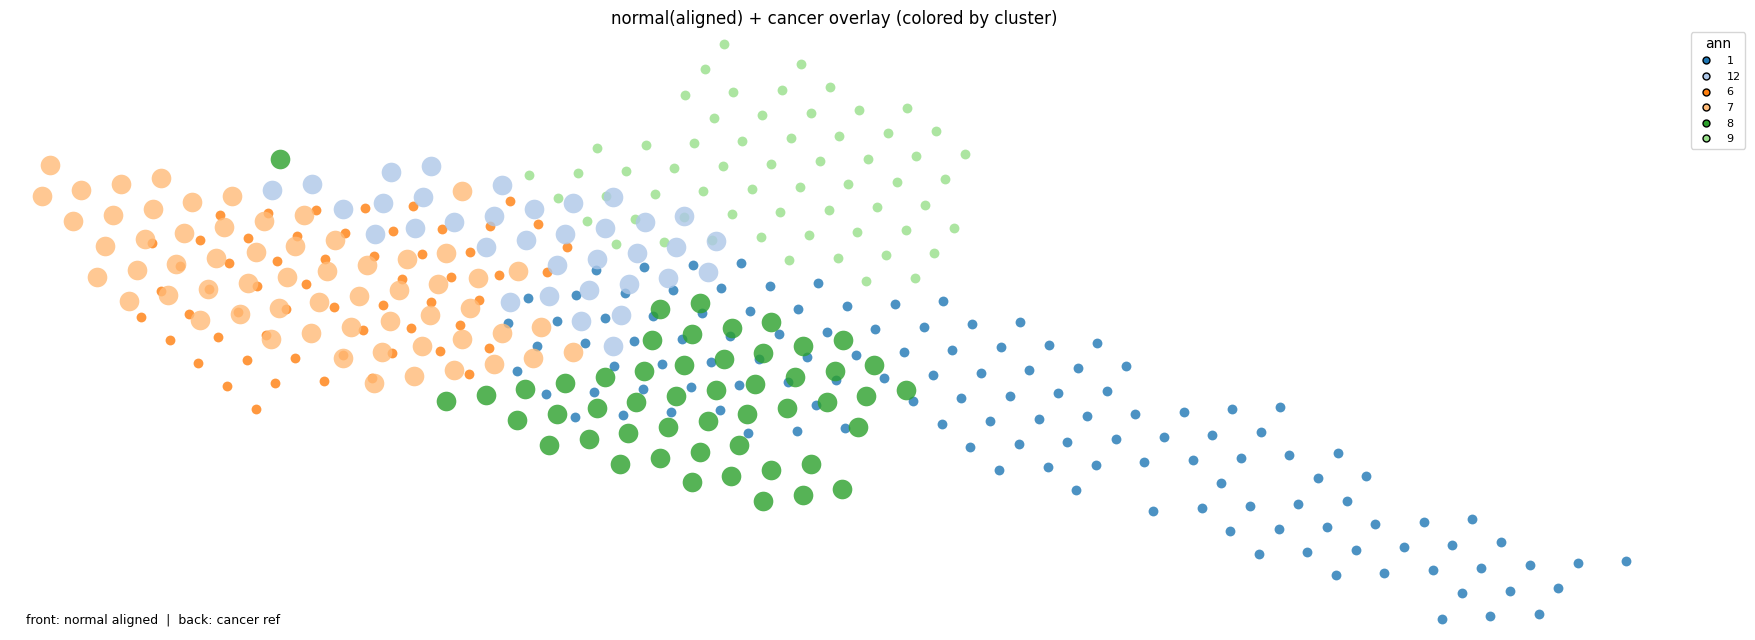

In [76]:
X_src_aligned = X_aligned
overlay_two_sets_by_ann(
    X_a=X_src_aligned,   
    X_b=X_ref,     
    s_a=200,
    s_b=50,      
    ann_a=ann_src,       
    ann_b=ann_ref,       
    label_a="normal aligned",
    label_b="cancer ref",
    title="normal(aligned) + cancer overlay (colored by cluster)",
    invert_y=True,
    legend=True
)

In [77]:
adata_l_normal = adata_lower_ds_no_pmc[adata_lower_ds_no_pmc.obs['status']=='normal']
adata_l_cancer = adata_lower_ds_no_pmc[adata_lower_ds_no_pmc.obs['status']=='cancer']

/tmp/ipykernel_1880088/3341676906.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_l_normal, color=["cluster"], spot_size=150)


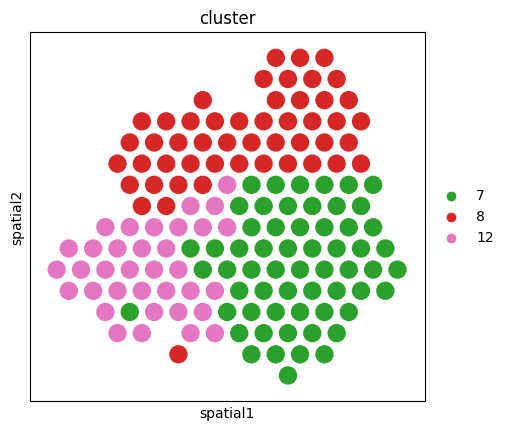

In [78]:
sc.pl.spatial(adata_l_normal, color=["cluster"], spot_size=150)

/tmp/ipykernel_1880088/2223029625.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_l_cancer, color=["cluster"], spot_size=150)


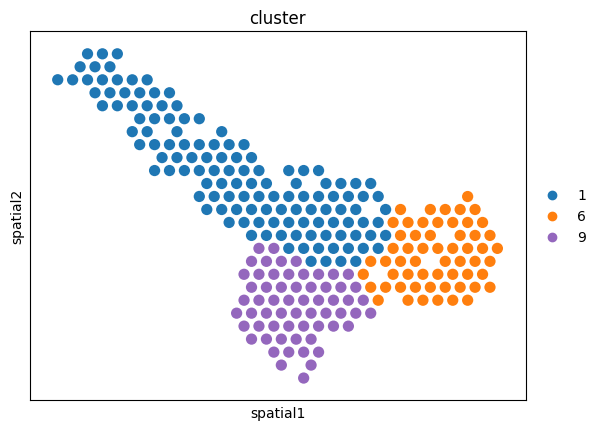

In [79]:
sc.pl.spatial(adata_l_cancer, color=["cluster"], spot_size=150)